In [1]:
#load the best models from the checkpoints folder

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.utils import to_categorical 
from tensorflow.keras.models import load_model, Model
import json
import helper
import plotly.express as px

MODEL_ID = 143#35
AVERAGED = None

2024-01-22 13:57:56.652430: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def get_model(model_id):
    params = []
    #load the json from params.json
    with open('params.json') as json_file:
        params = json.load(json_file)
    params = params[model_id]
    print(params)
    model = load_model('checkpoints/best_model_{}.h5'.format(model_id), compile=False)
    return model, params

In [3]:
#load the data
def avg(group, group_size): 
        group['GroupNumber'] = np.array(range(len(group.index))) // group_size
        res = group.groupby('GroupNumber').mean()
        return res
def get_data(model,params,averaged):
    group_size = params['group_size'] if averaged == None else averaged
    
    data = pd.read_hdf("../../initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
    #print all the columns
    ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
    data = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                        (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]
    data = data.groupby(['Peptide', 'Time', 'Replicate', 'Concentration']).apply(avg, group_size=group_size)
    scaling_factor = 1024/(params['output_range'][1]-params['output_range'][0])
    X = np.array(data.values)/scaling_factor + params['output_range'][0]
    reconstructedX = model(X)
    return X, reconstructedX, data.columns


In [4]:
def get_plots(X,reconstructedX,group_size,params,columns):
    #plot for each of the 26 columns X vs reconstructedX
    plt.figure(figsize=(15, 15))
    plt.suptitle("Group size {}, trained on group size {}".format(group_size,params['group_size']), fontsize=16)
    r_squared = []
    for i in range(len(columns)):
        plt.subplot(6, 5, i + 1)
        #scatter with opacity 0.1
        plt.scatter(X[:,i], reconstructedX[:,i], alpha=1, s=1)
        plt.title(columns[i])
        plt.xlabel("X")
        plt.xlim([-1, 1])
        plt.ylim([-1, 1])    
        #plot y=x
        #calculate R2 score
        r2 = np.corrcoef(X[:,i], reconstructedX[:,i])[0,1]**2
        r_squared.append(r2)
        plt.text(-0.9, 0.8, "R2: {:.4f}".format(r2))
        plt.plot([-1, 1], [-1, 1], color='red', linewidth=1)
        plt.ylabel("reconstructedX")
    plt.tight_layout()
    plt.show()

    #sort the columns by R2 score  
    r_squared, sorted_columns = zip(*sorted(zip(r_squared, columns)))
    plt.figure(figsize=(5, 3))
    plt.suptitle("Group size {}, trained on group size {}".format(group_size,params['group_size']), fontsize=16)
    plt.bar(sorted_columns, r_squared)
    plt.xticks(rotation=90)
    plt.ylabel("R2 score")
    plt.show()

{'group_size': 100, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 143}


2024-01-22 13:58:00.823583: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-01-22 13:58:00.823800: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


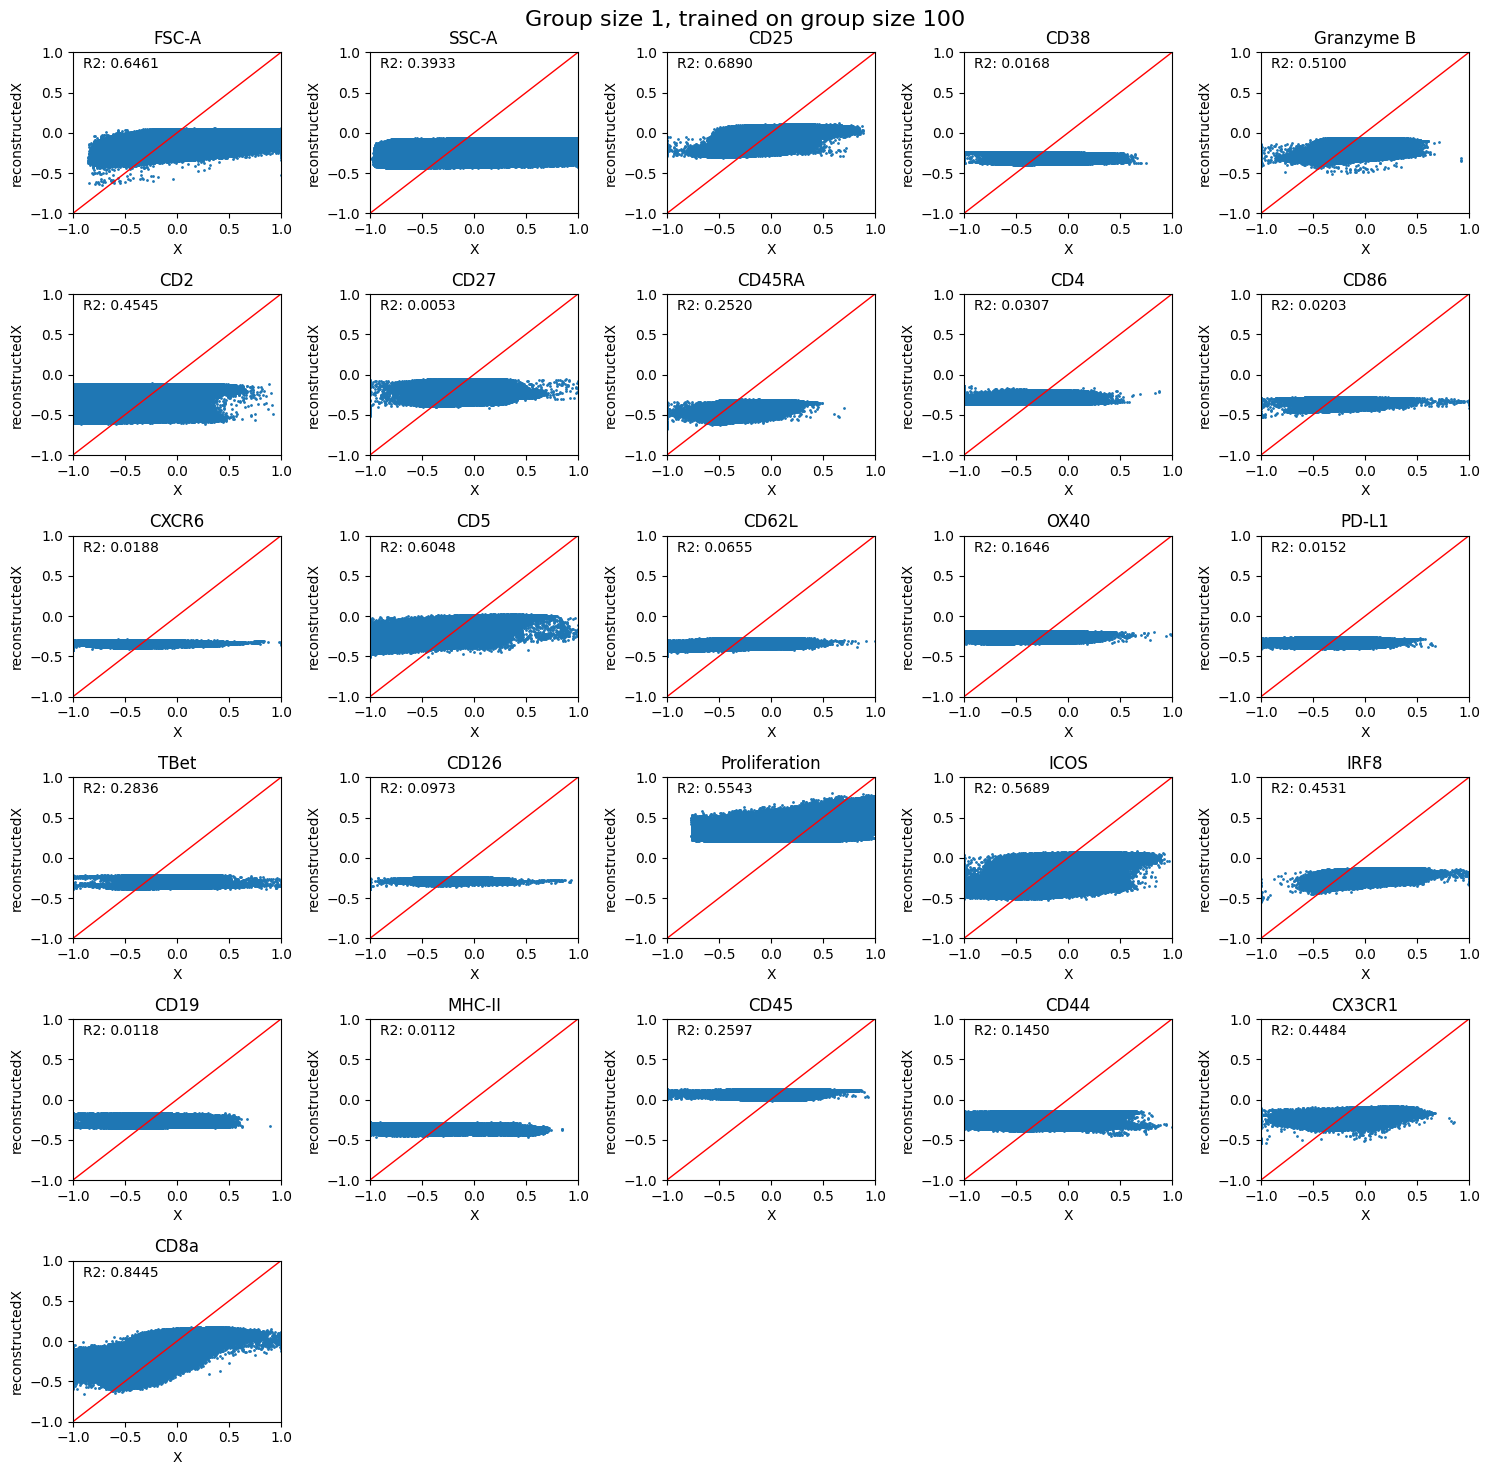

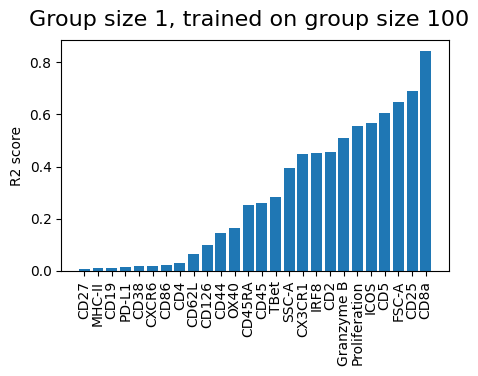

{'group_size': 100, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 143}


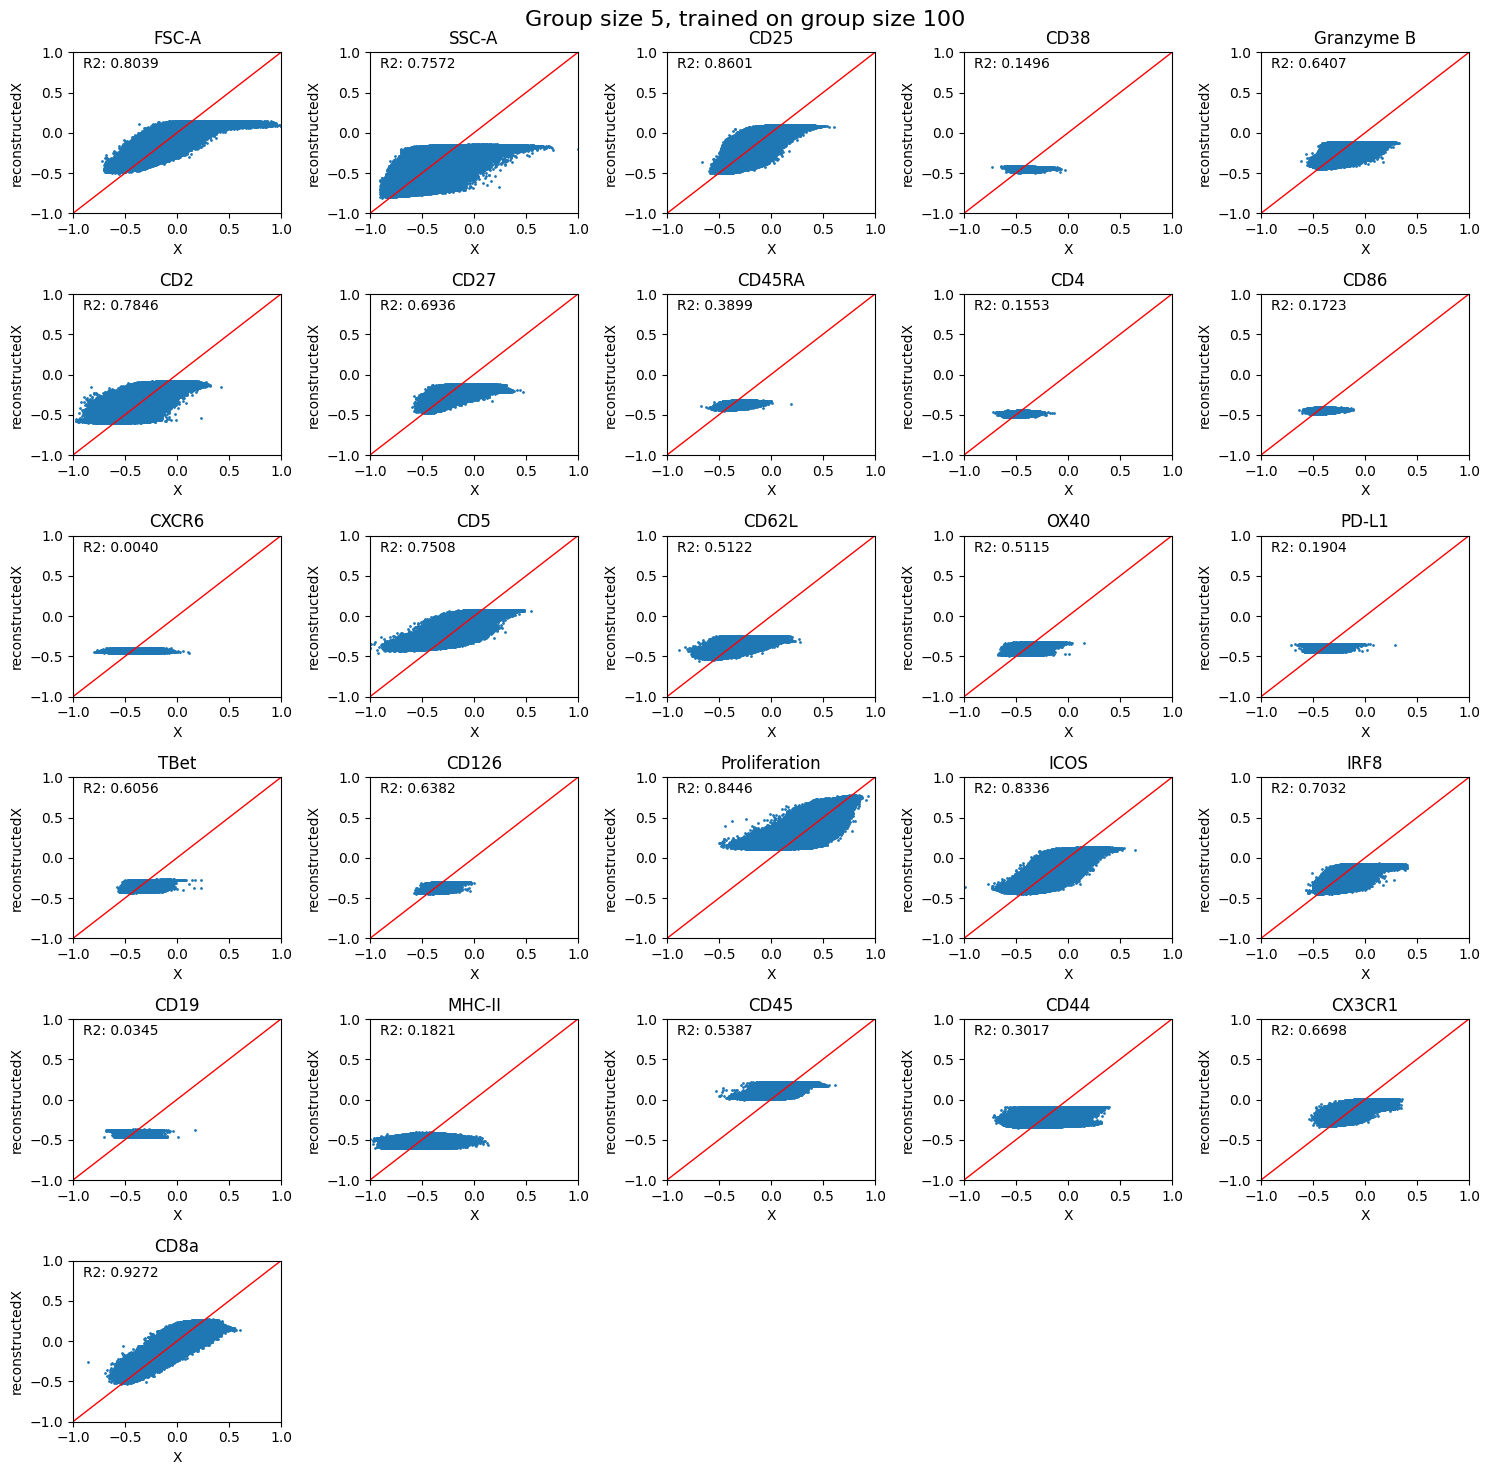

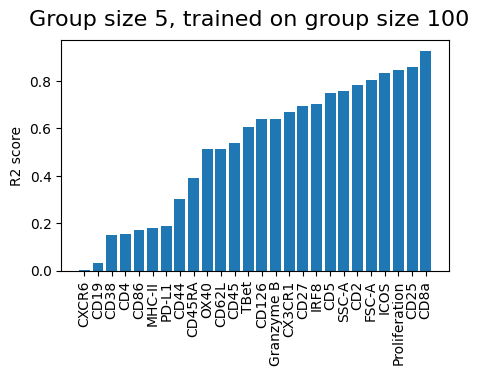

{'group_size': 100, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 143}


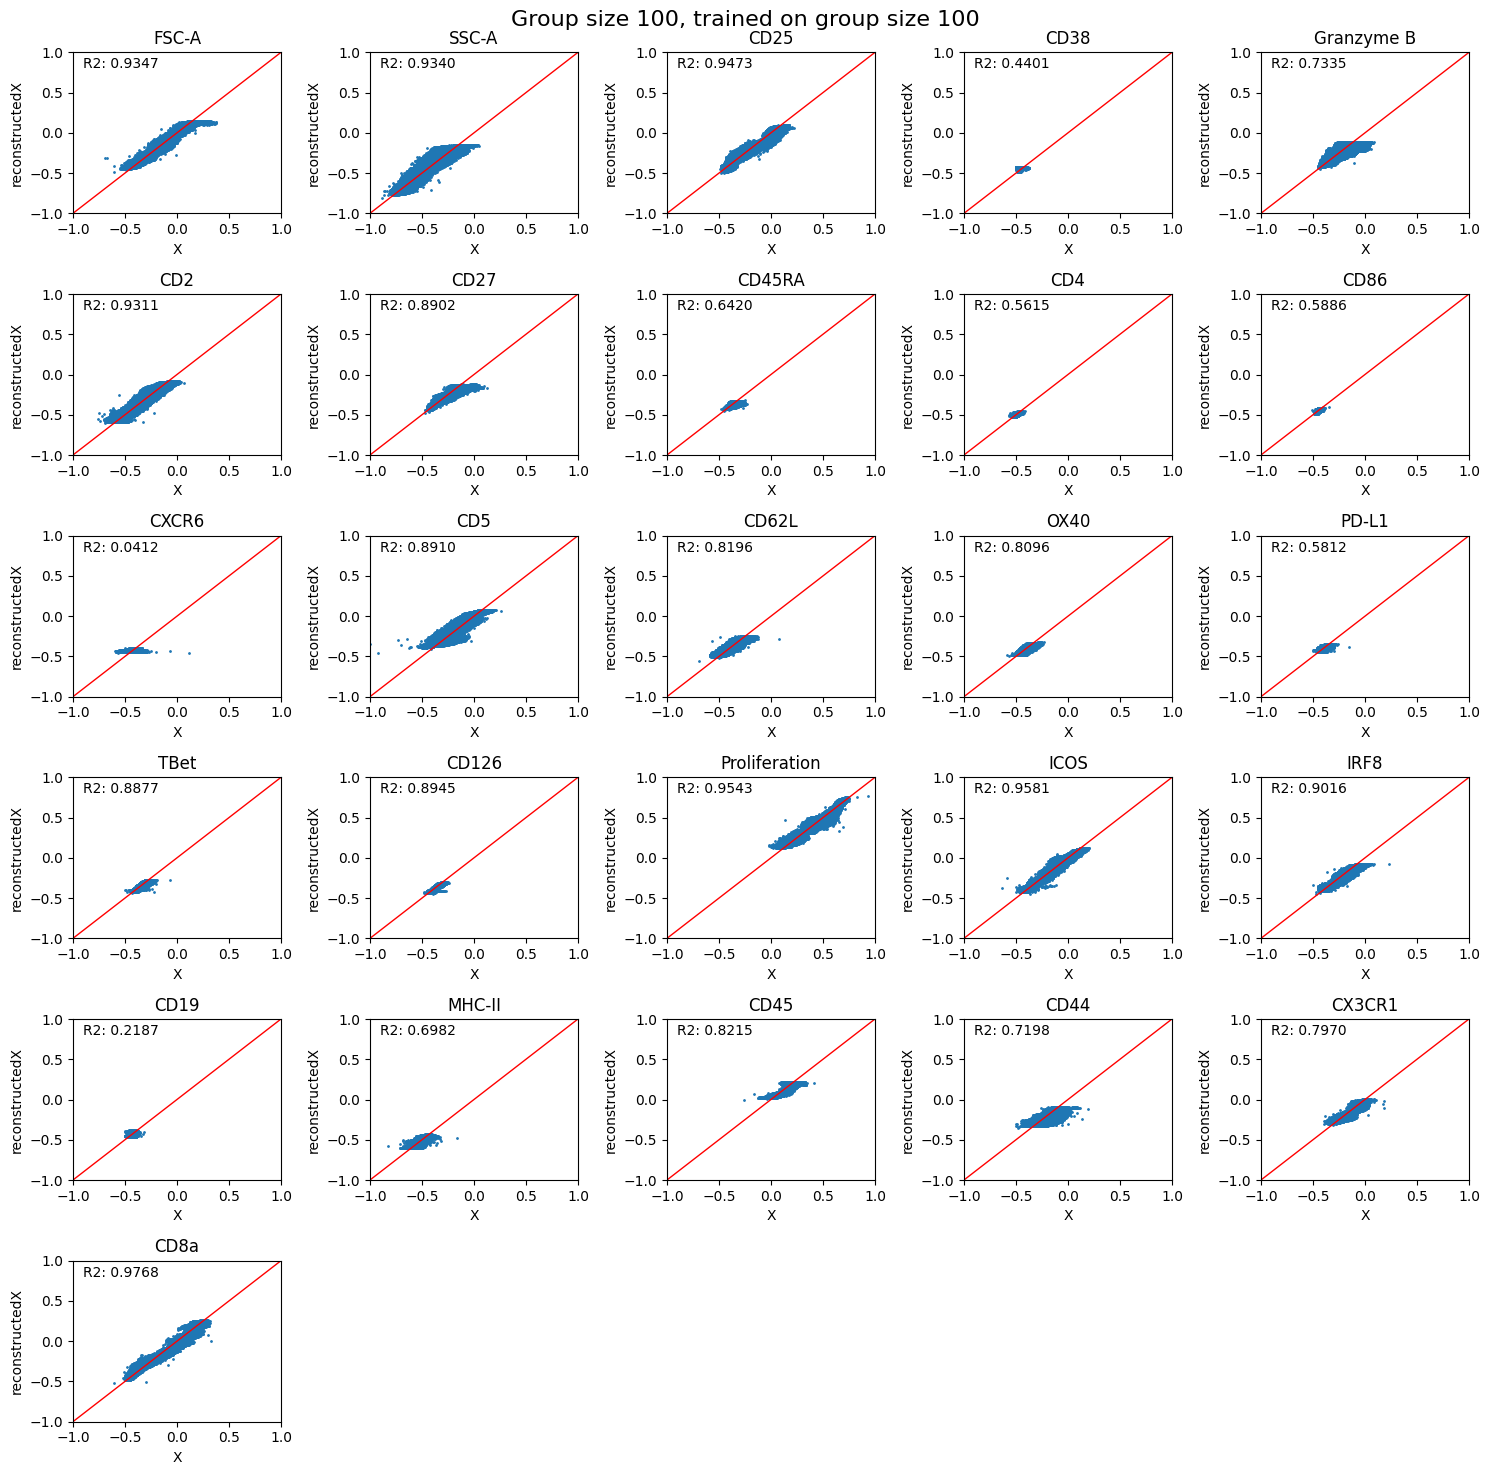

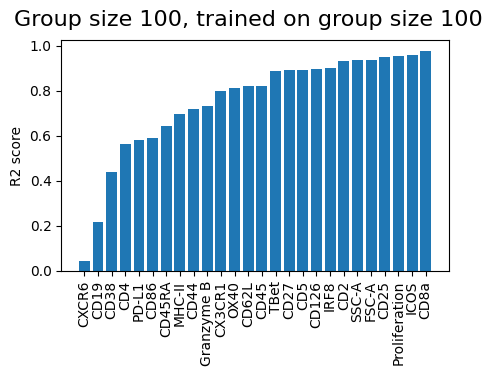

{'group_size': 25, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.5, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 106}


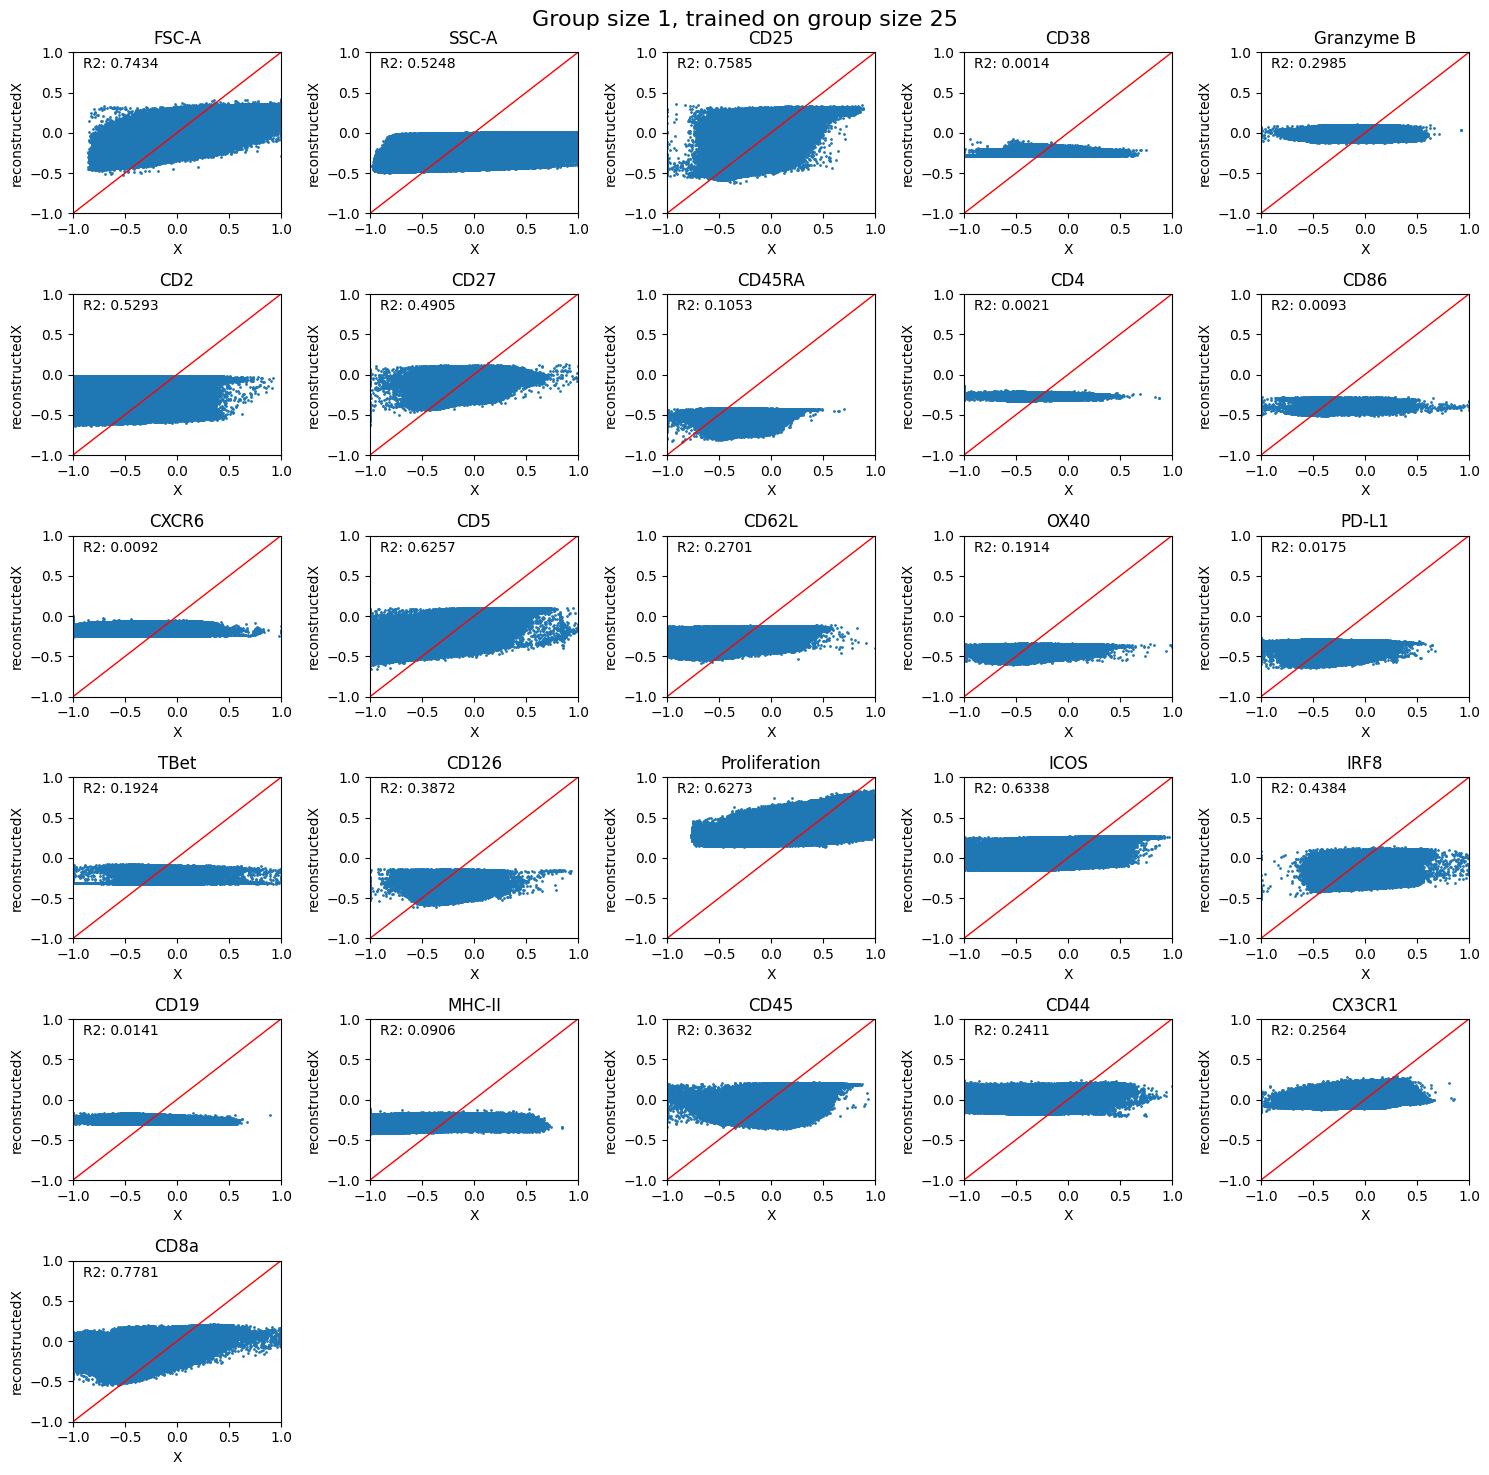

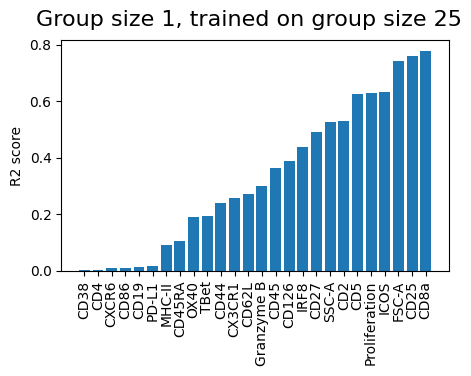

{'group_size': 25, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.5, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 106}


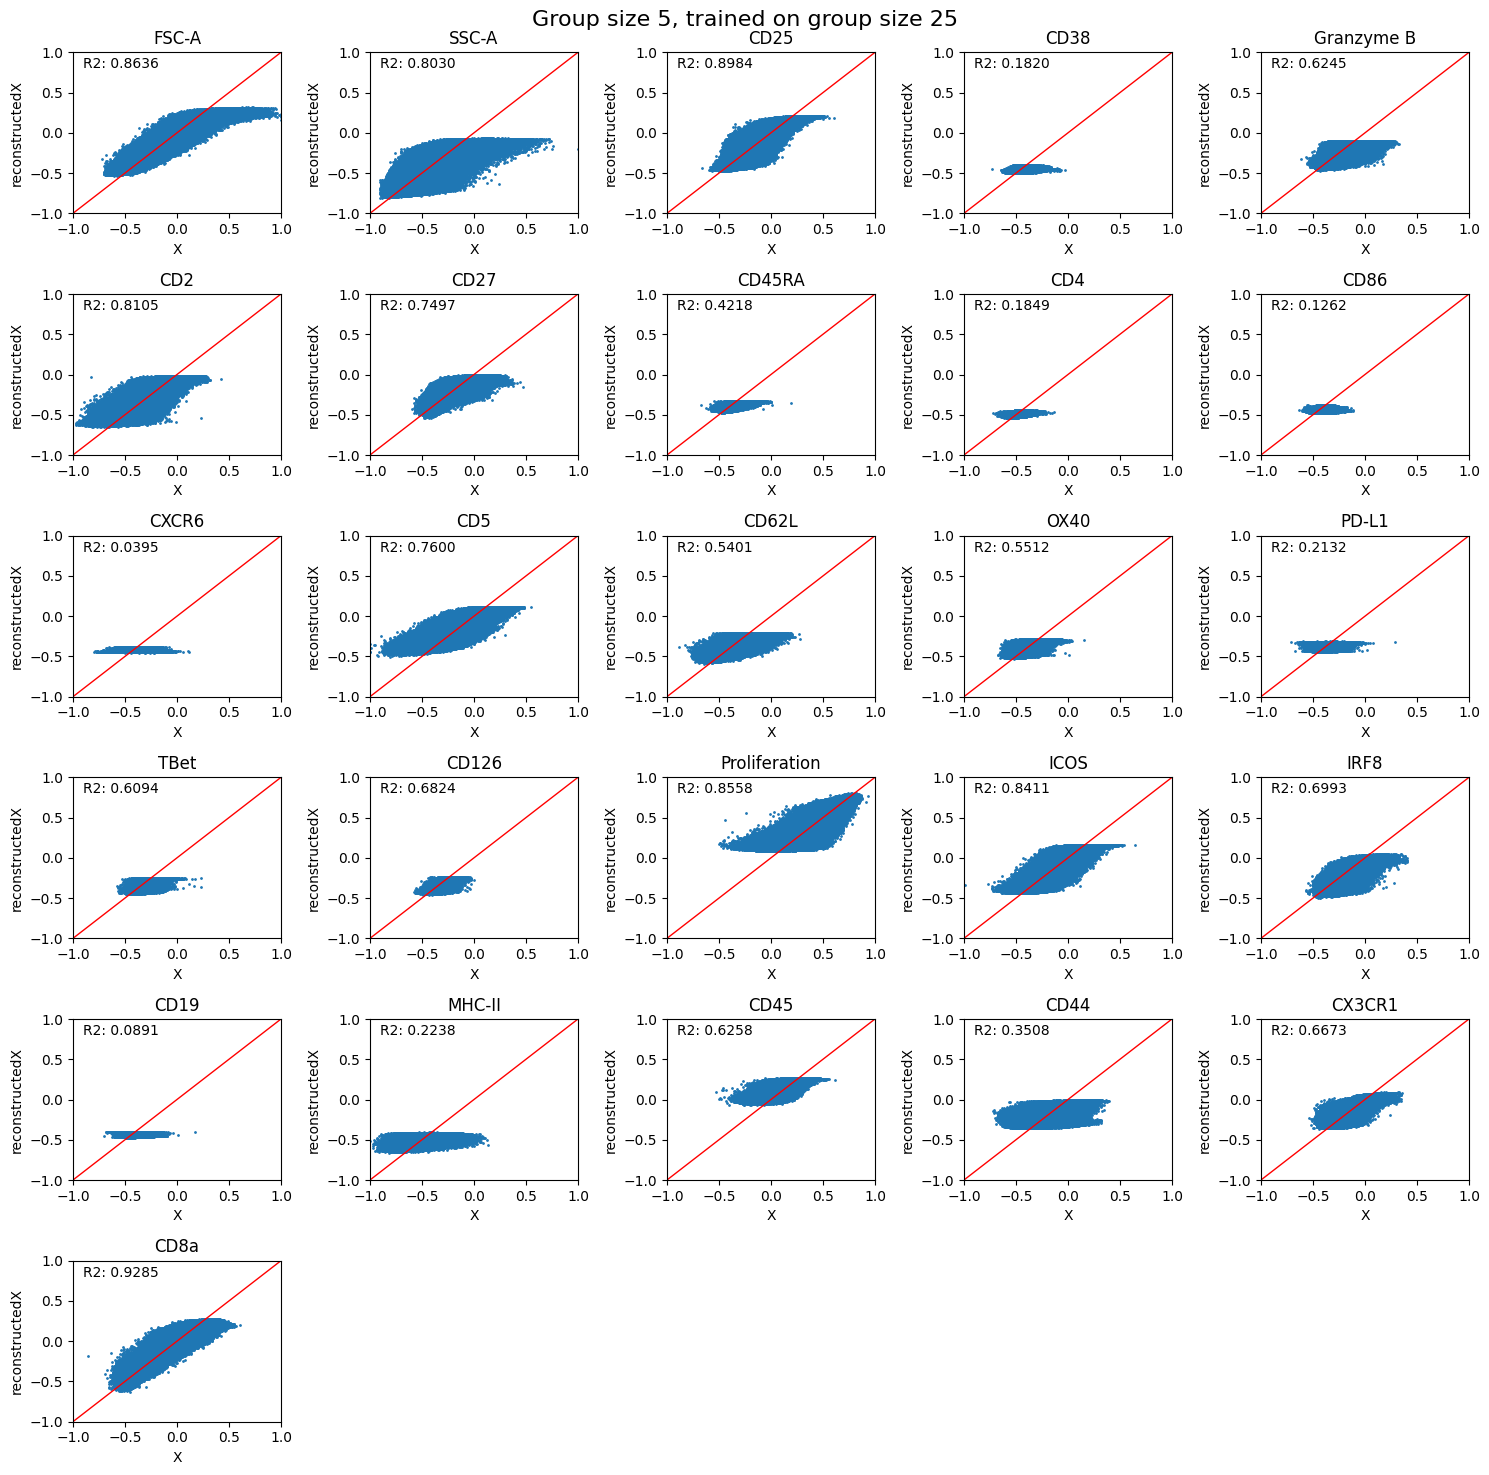

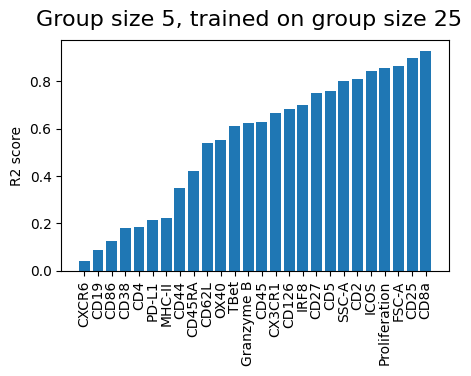

{'group_size': 25, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.5, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 106}


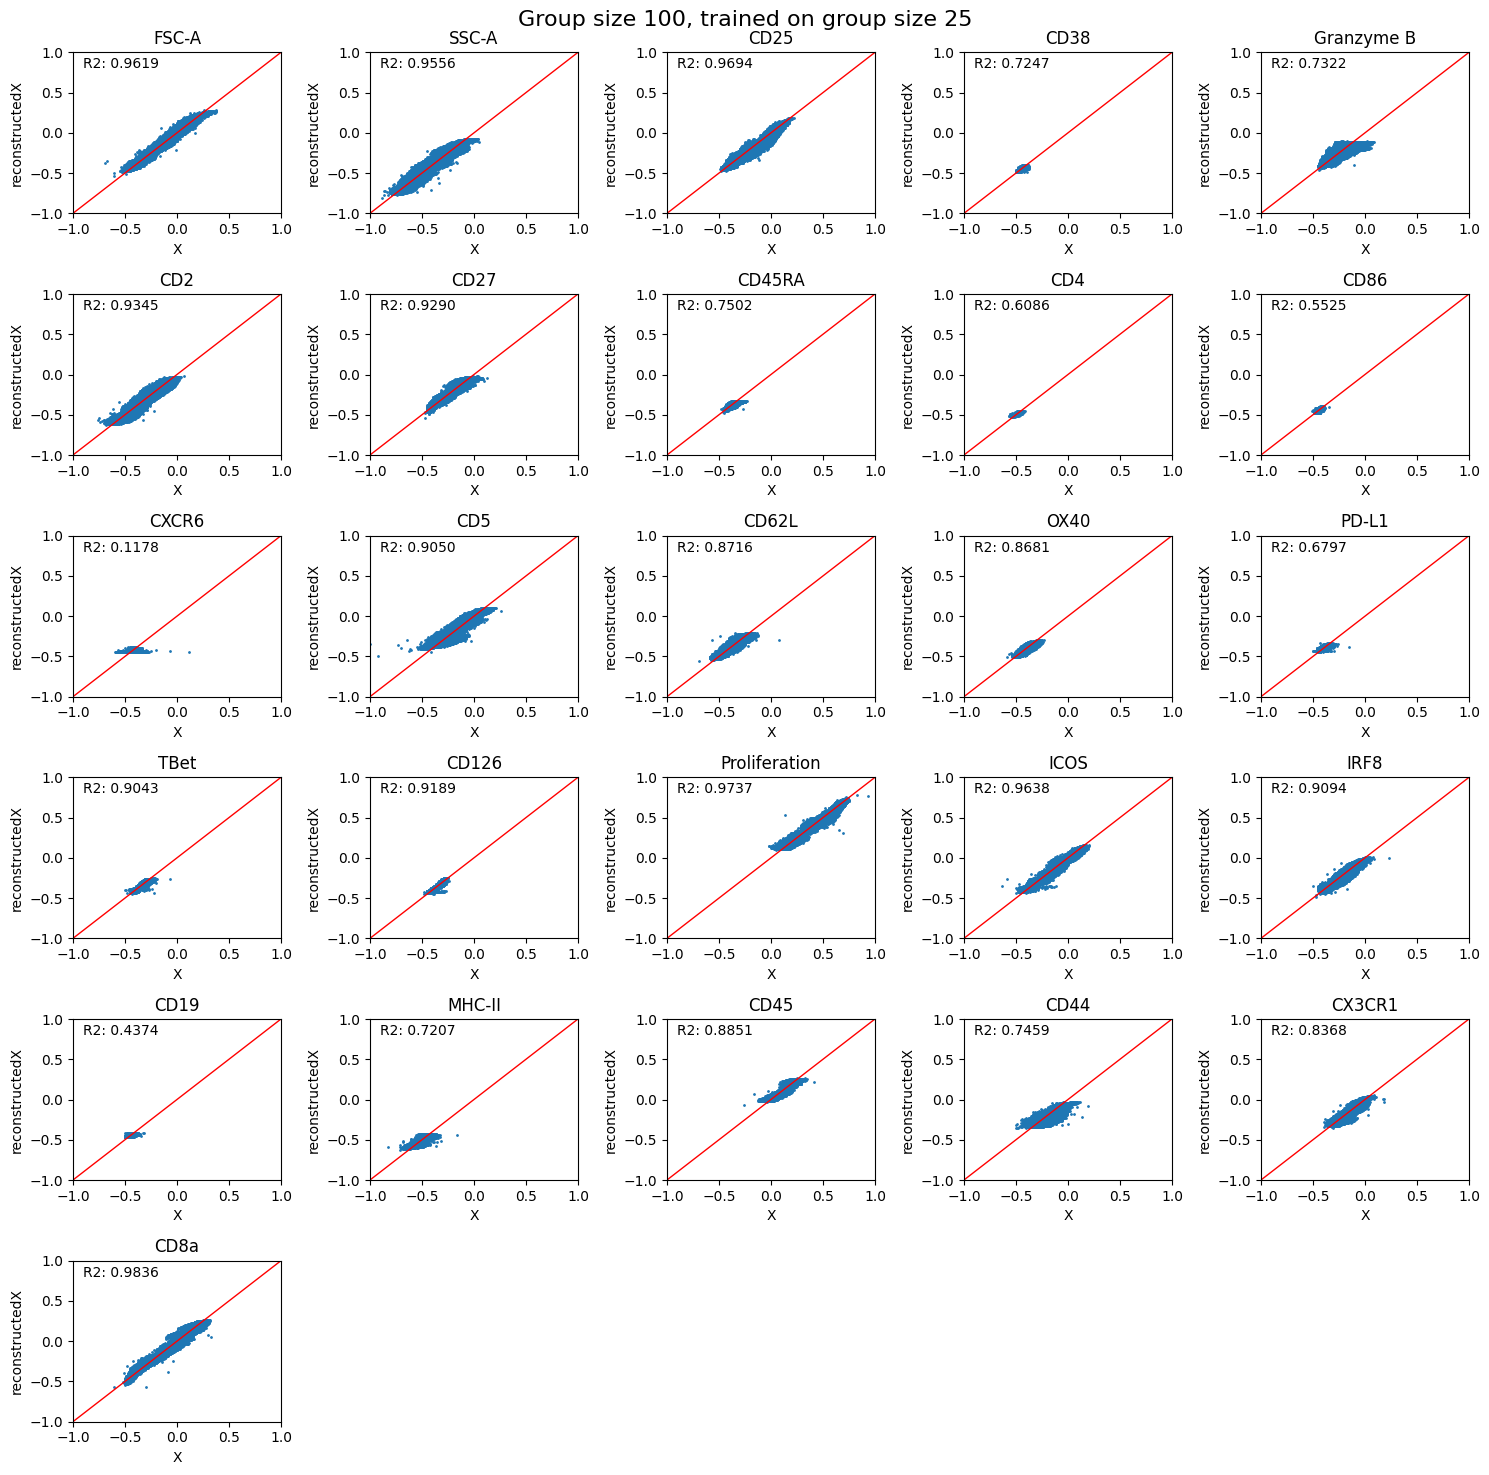

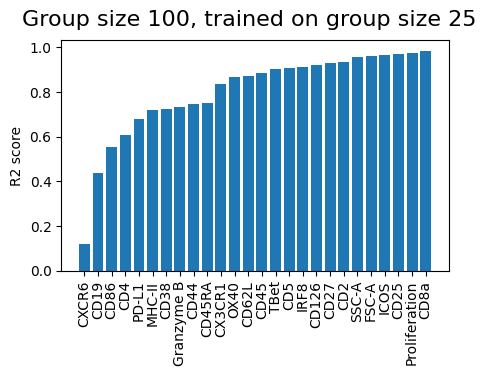

{'group_size': 10, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.5, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 70}


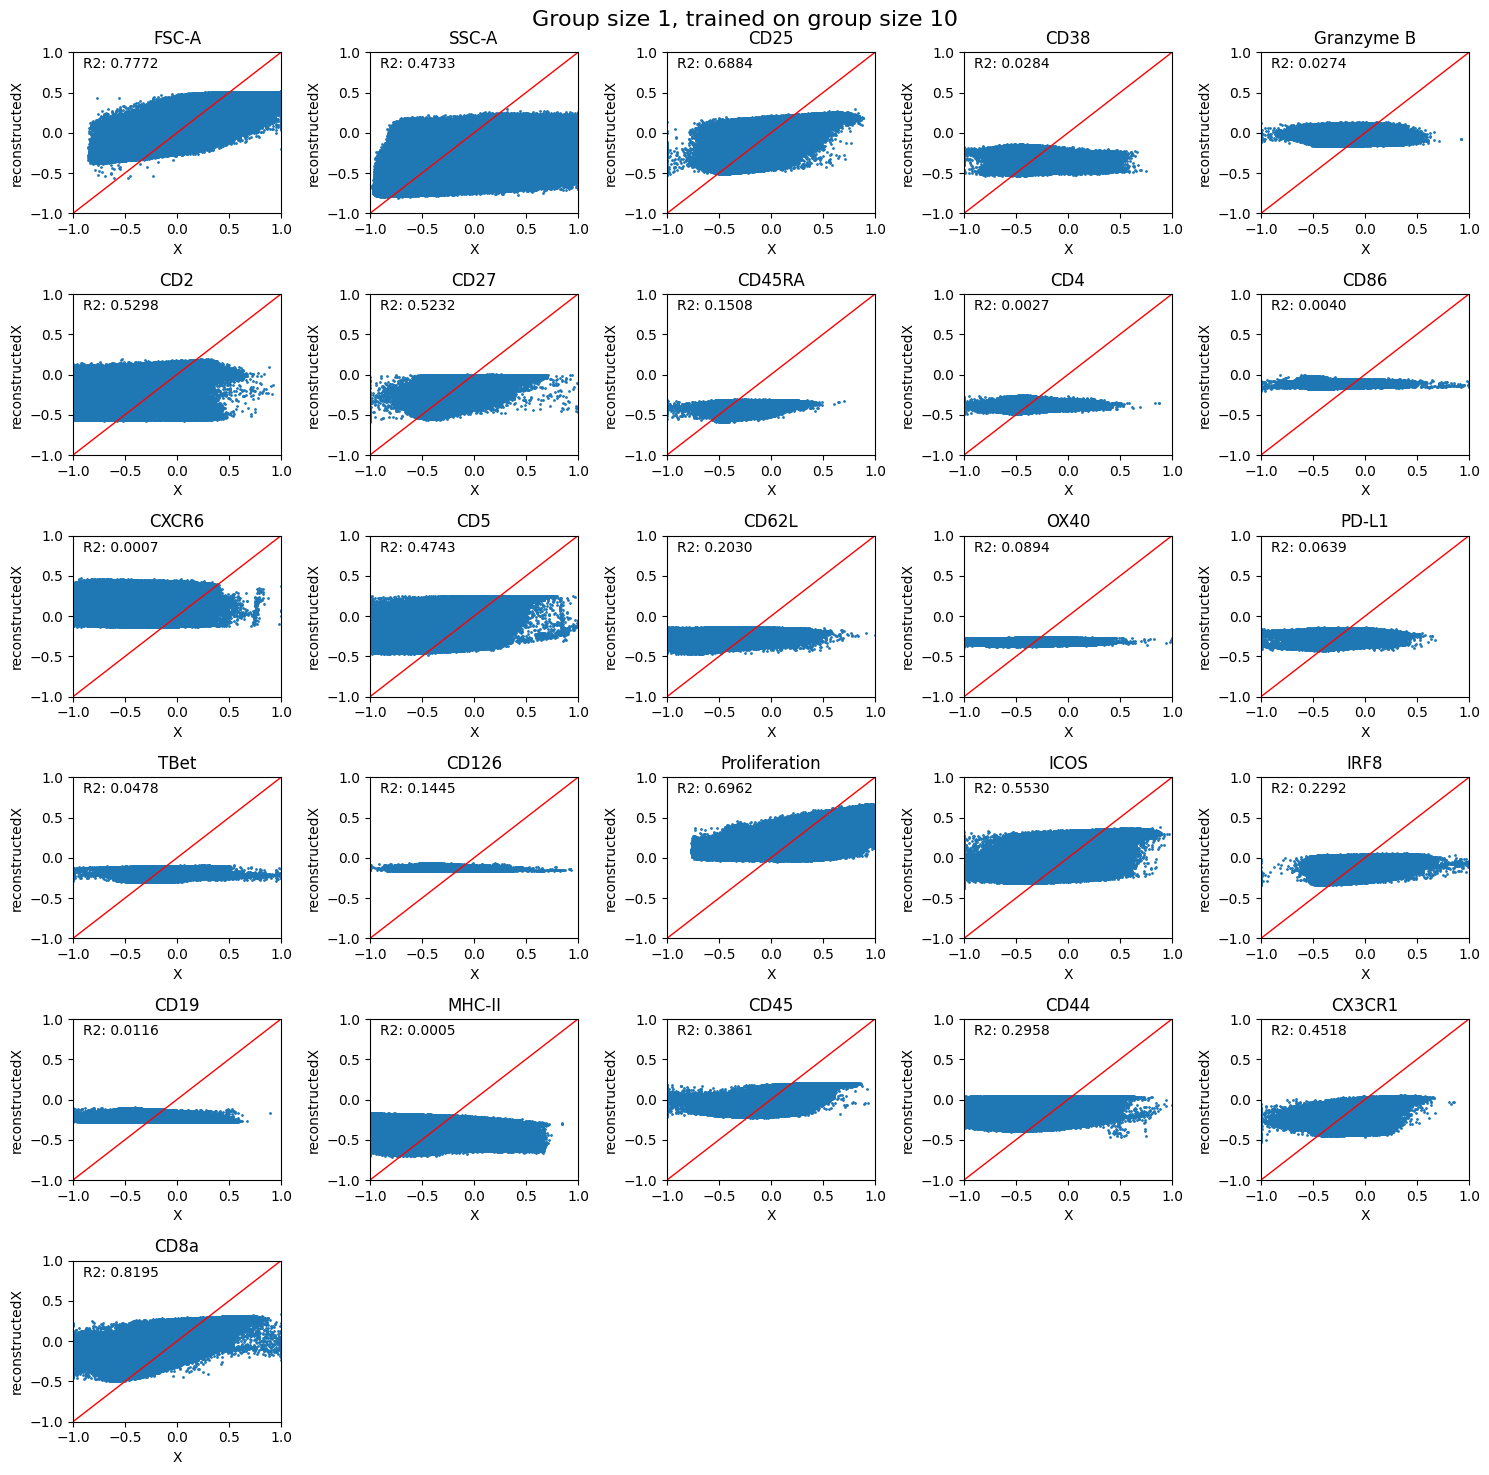

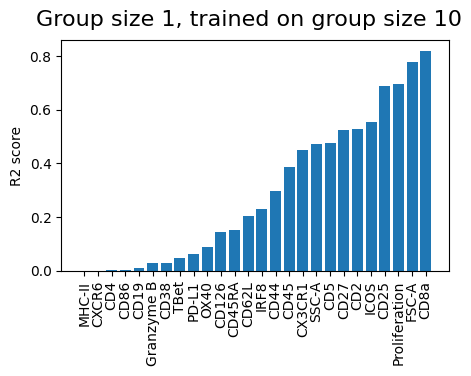

{'group_size': 10, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.5, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 70}


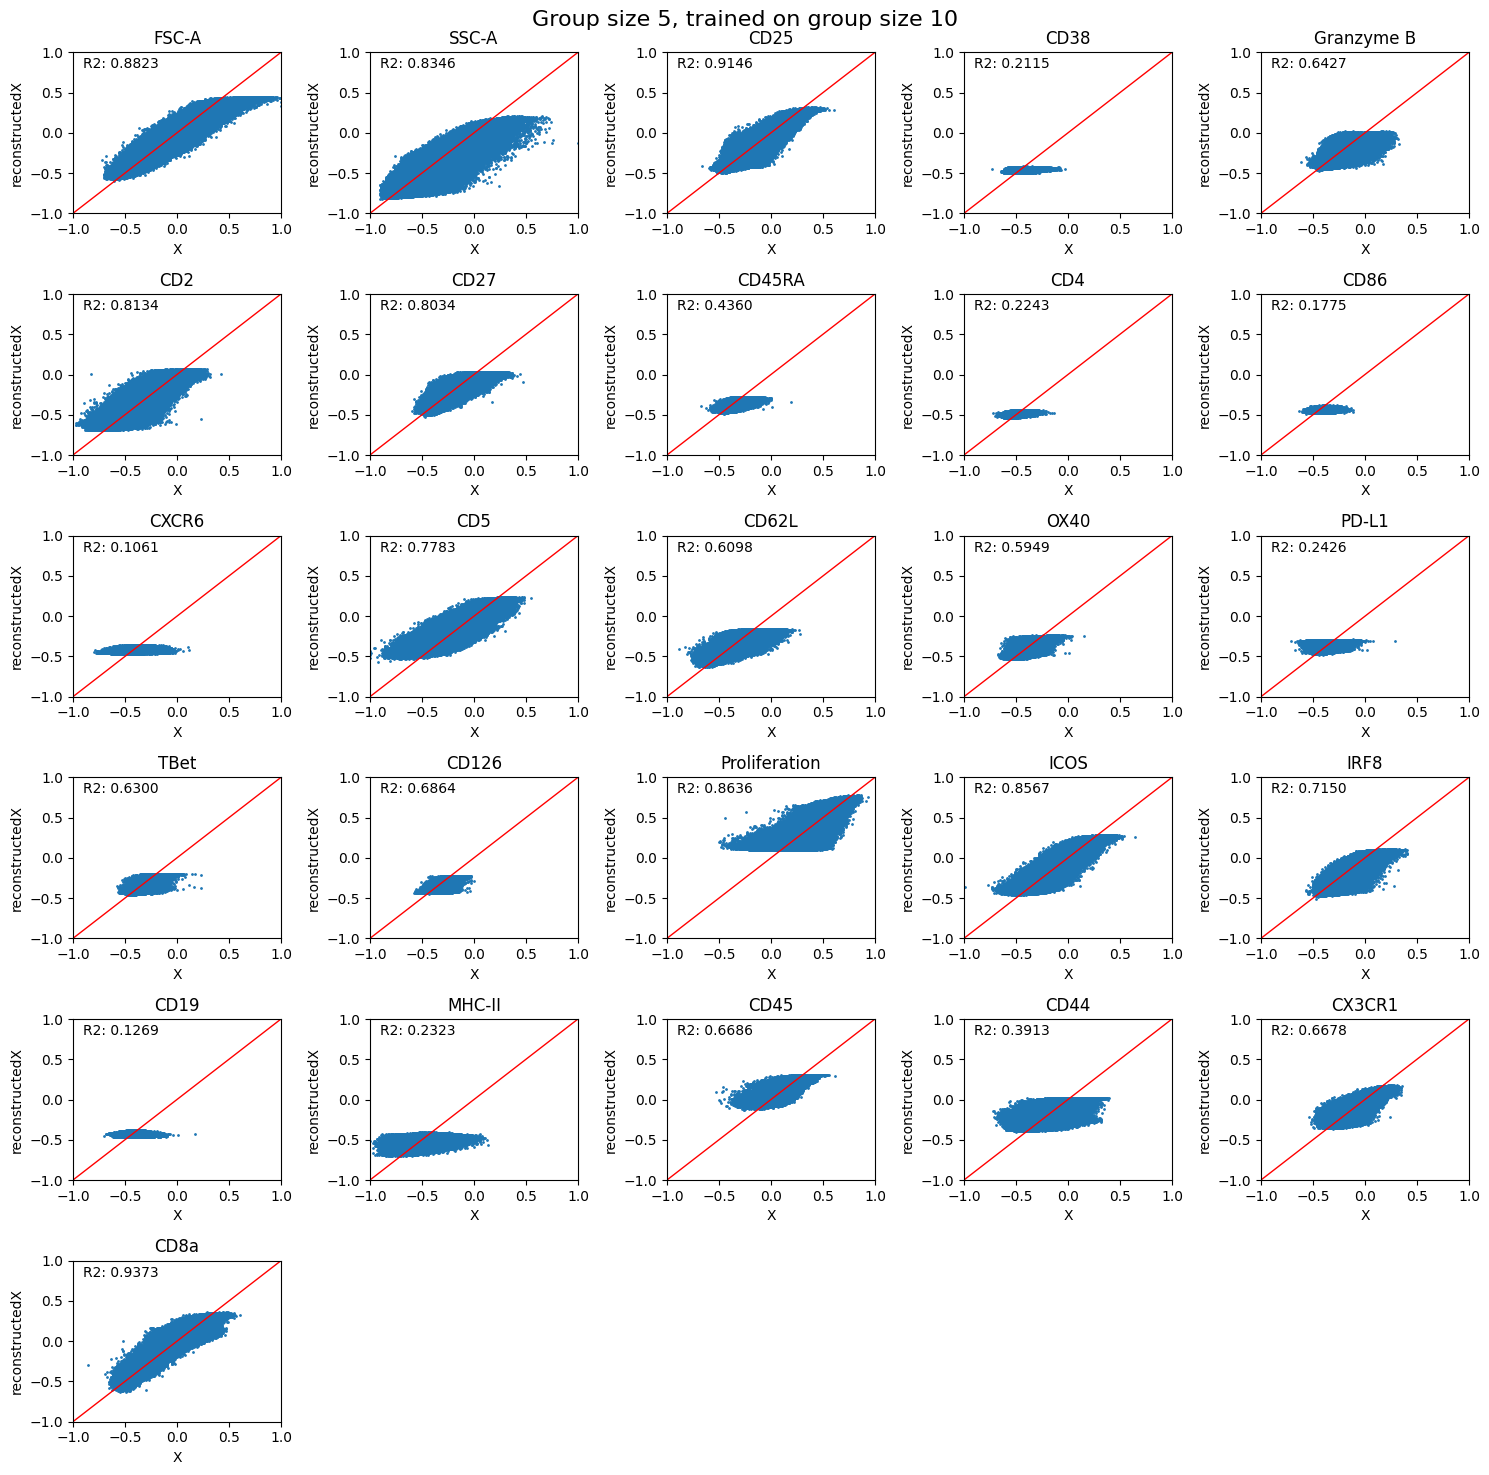

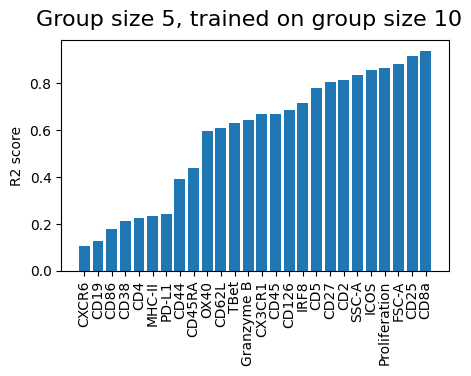

{'group_size': 10, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.5, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 70}


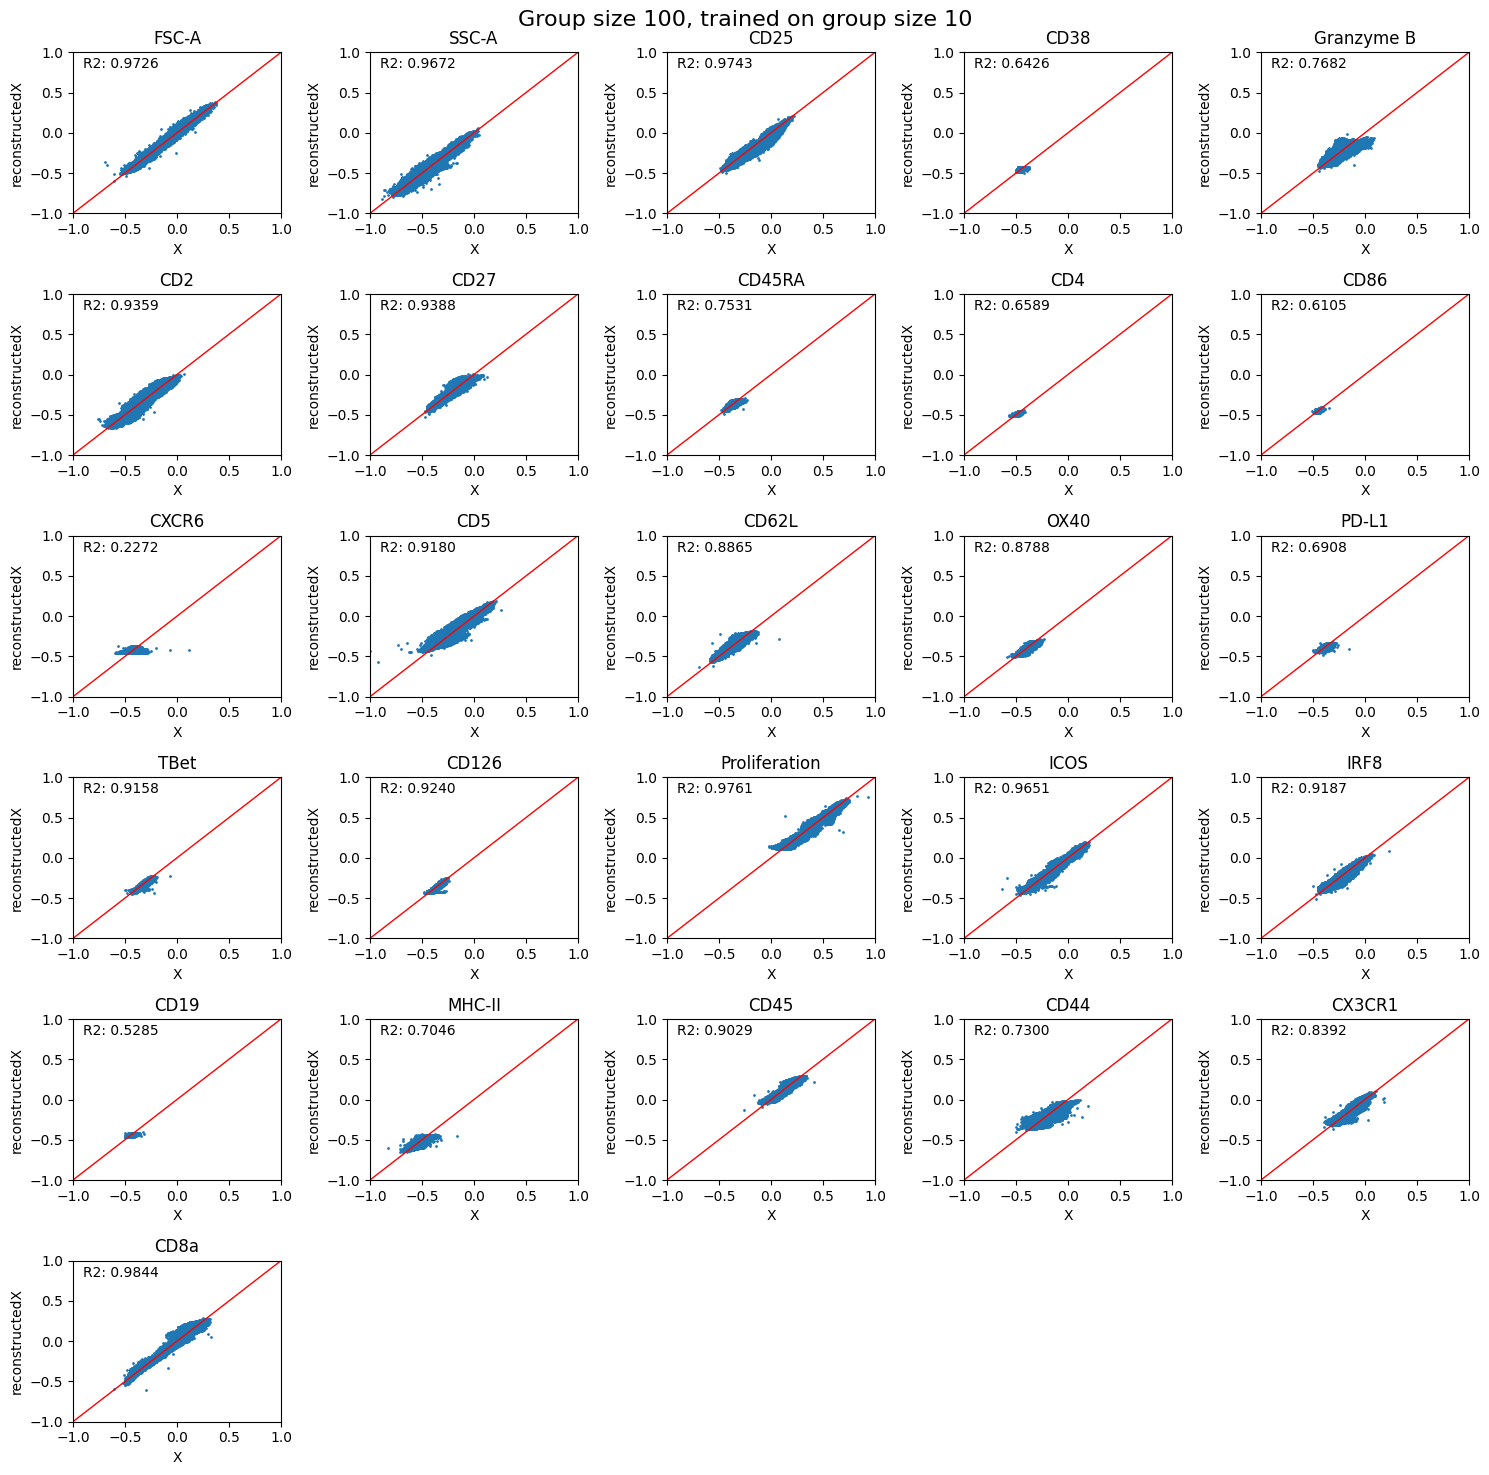

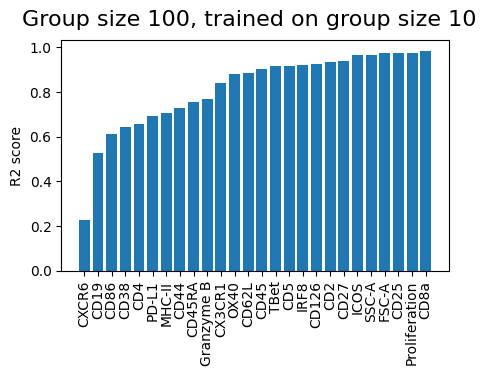

{'group_size': 1, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 35}


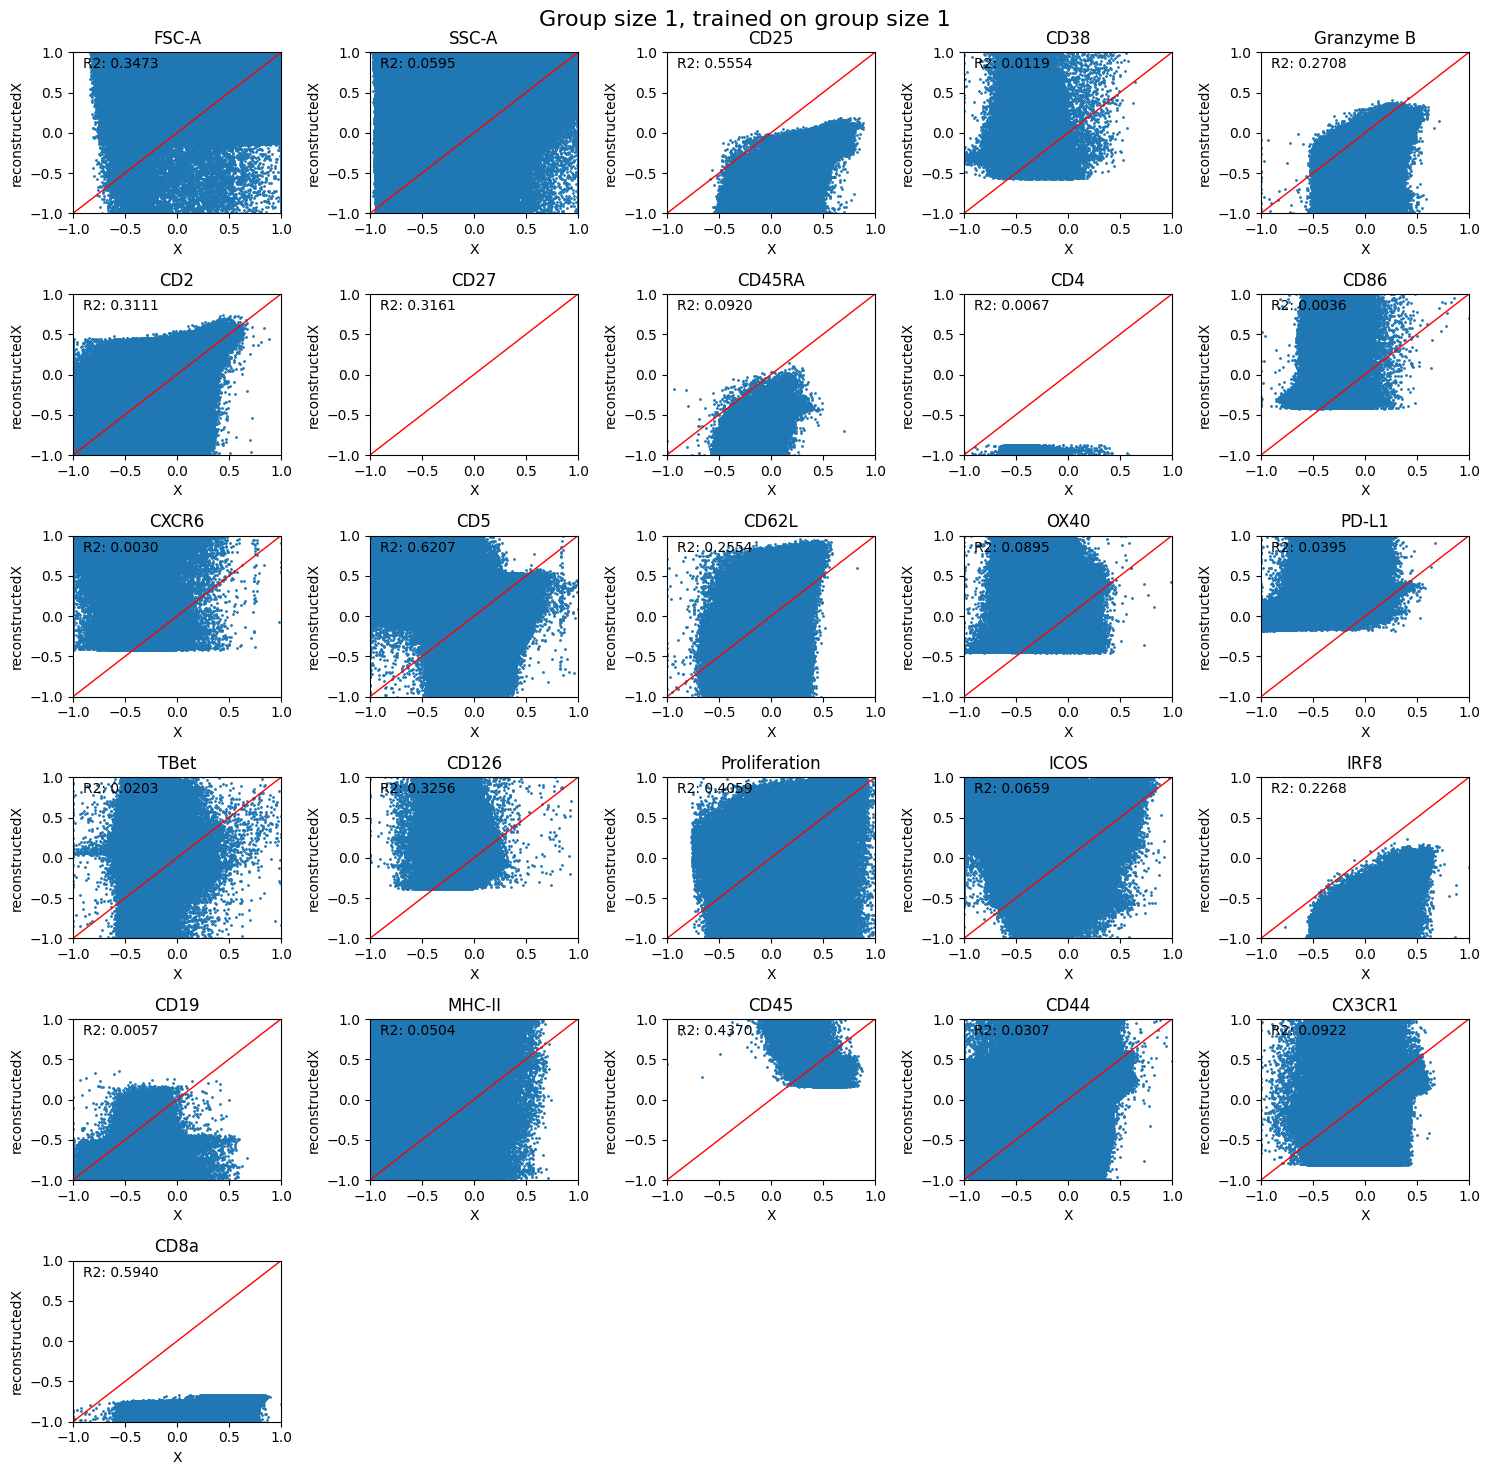

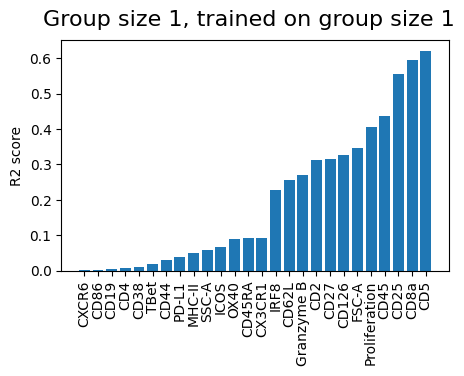

{'group_size': 1, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 35}


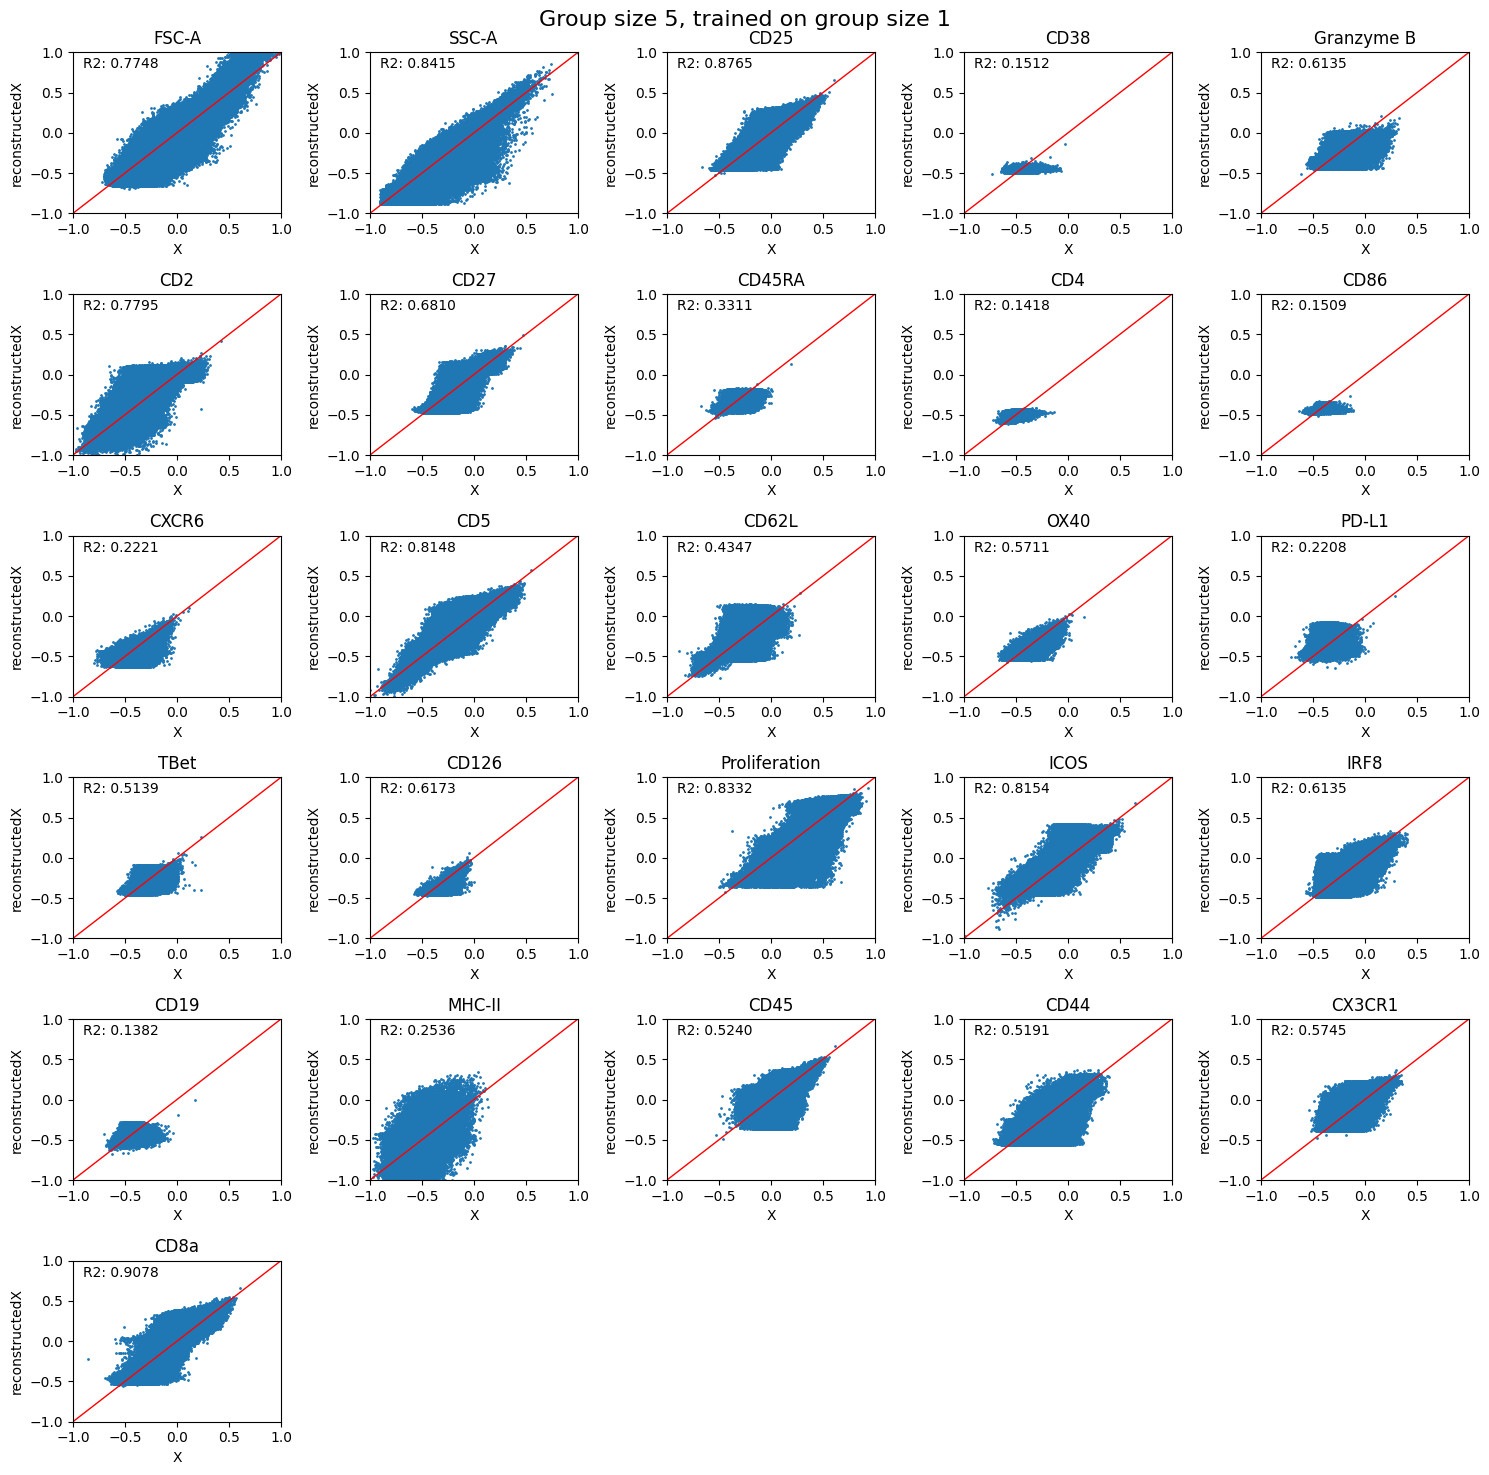

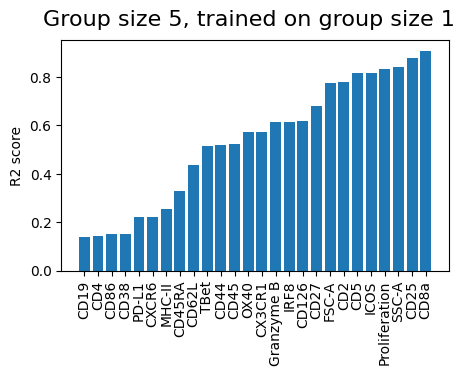

{'group_size': 1, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 35}


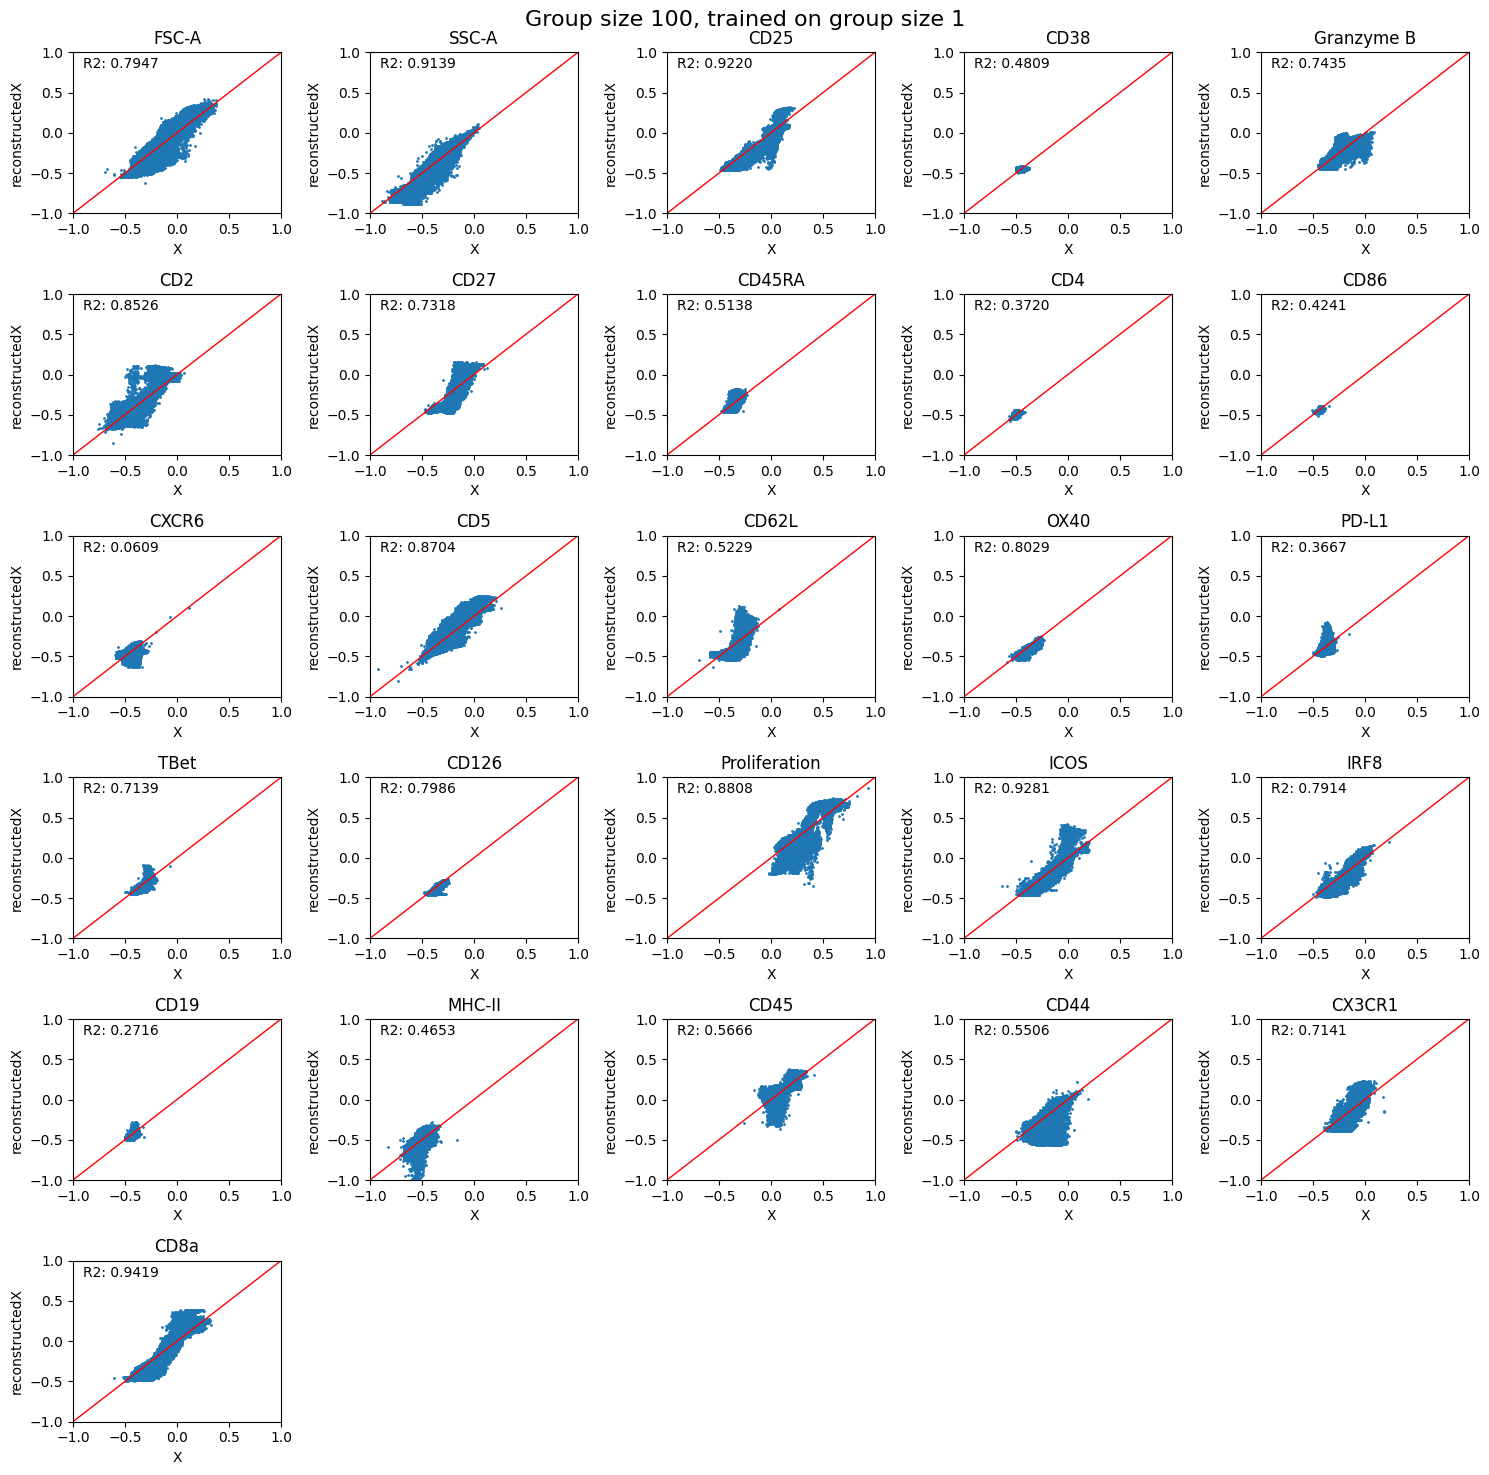

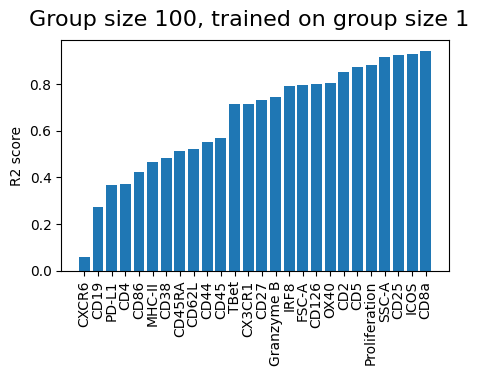

In [5]:
for model_id in [143, 106, 70, 35]:
    for averaged in [1,5,100]:
        model, params = get_model(model_id)
        X, reconstructedX, columns = get_data(model,params,averaged)
        get_plots(X,reconstructedX,averaged,params,columns)
        del model, params, X, reconstructedX, columns

In [6]:
model, params = get_model(143)
all_r2_scores = []
cols =[]
averaged_sizes = range(1,50)
for averaged in averaged_sizes:
    X, reconstructedX, columns = get_data(model,params,averaged)
    cols = columns
    r2_scores = []
    for i in range(len(columns)):
        r2 = np.corrcoef(X[:,i], reconstructedX[:,i])[0,1]**2
        r2_scores.append(r2)
    all_r2_scores.append(r2_scores)
    del X, reconstructedX, columns
all_r2_scores = np.array(all_r2_scores)

{'group_size': 100, 'TEST_PROPORTION': 0.2, 'epochs': 1000, 'batch_size': 256, 'output_range': [-1, 1], 'between_layers': 4, 'first_layer_size': 256, 'layer_size_factor': 0.75, 'bottleneck_size': 2, 'num_features': 26, 'bottleneck_activation': 'linear', 'output_activation': 'linear', 'id': 143}


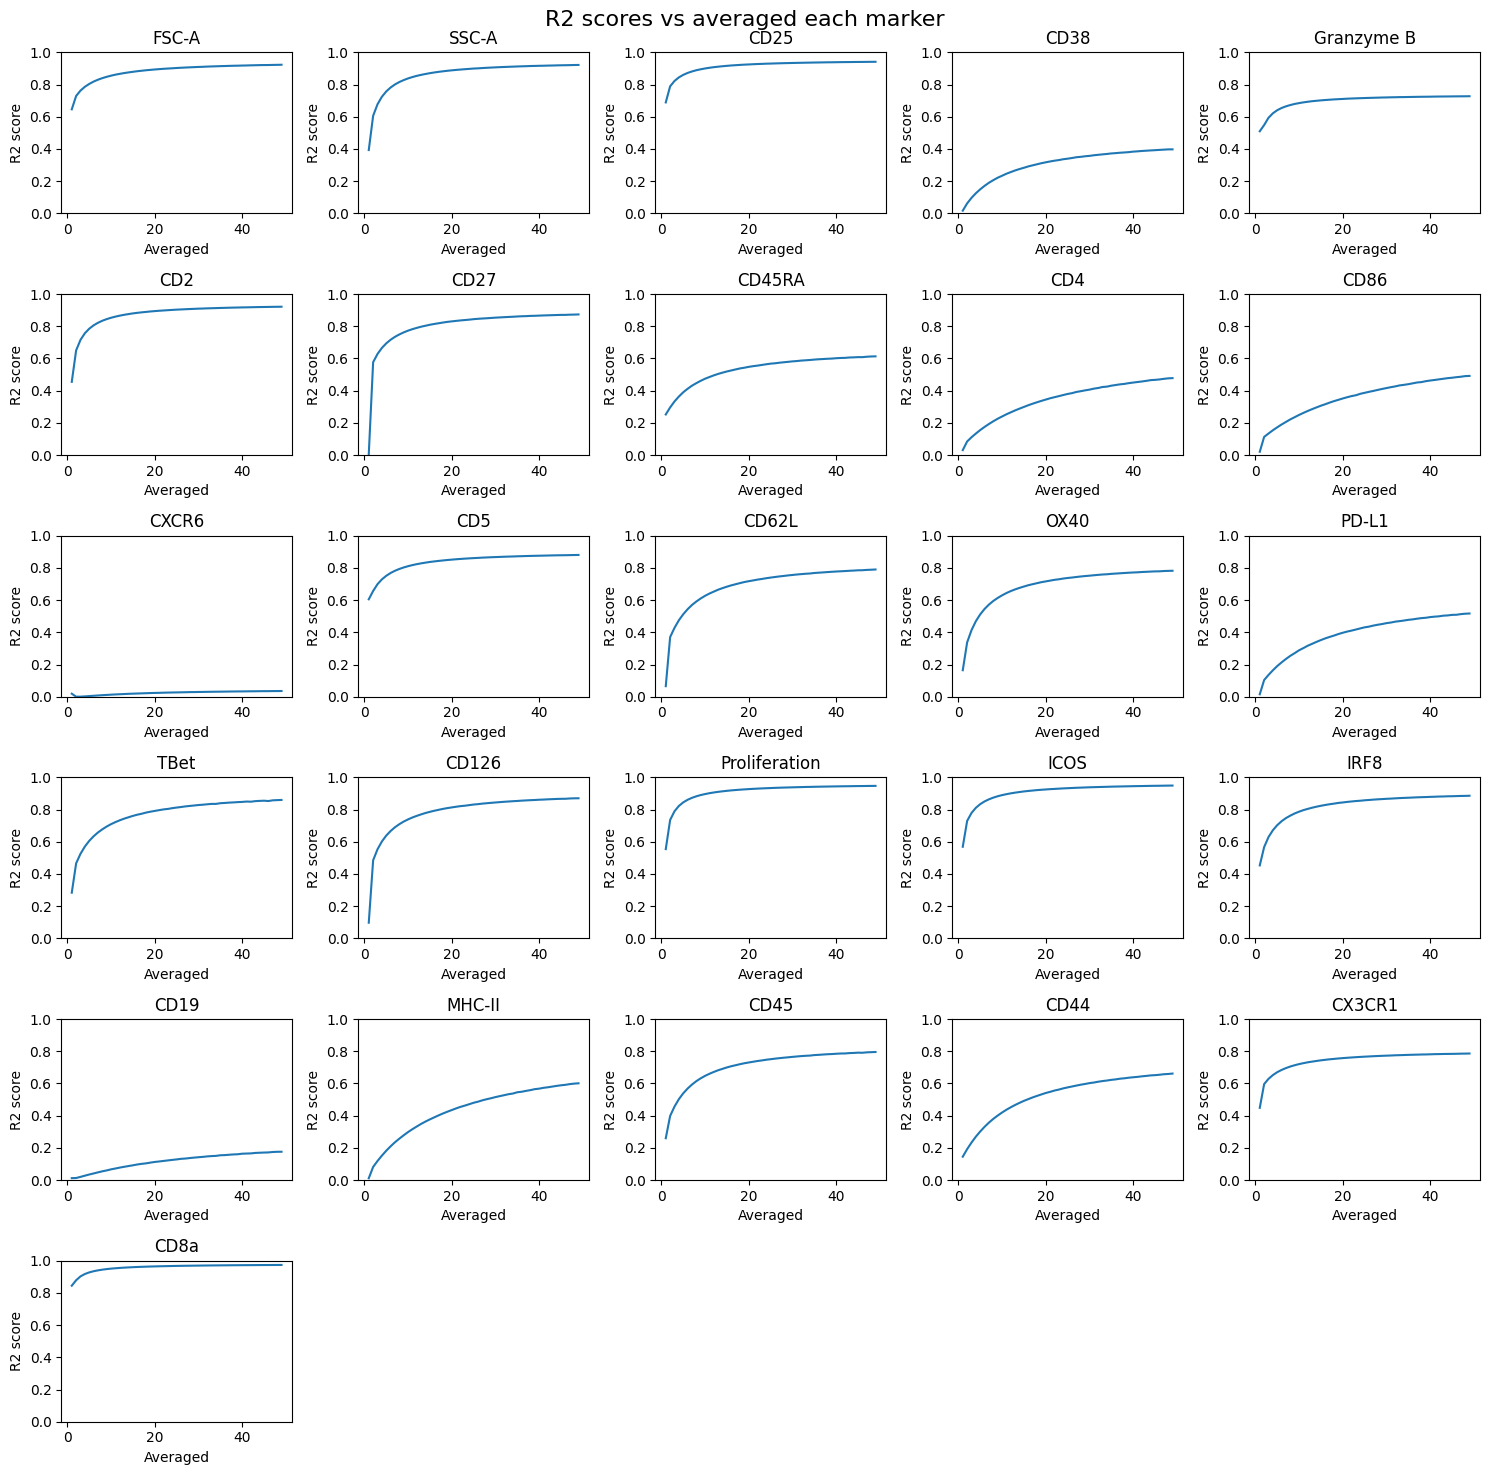

In [8]:
#plot the R2 scores vs averaged each column with matplotlib in separate plots
plt.figure(figsize=(15, 15))
plt.suptitle("R2 scores vs averaged each marker", fontsize=16)

for i in range(len(cols)):
    plt.subplot(6, 5, i + 1)
    #line plot
    plt.plot(averaged_sizes, all_r2_scores[:,i])
    plt.title(cols[i])
    plt.xlabel("Averaged")
    plt.ylabel("R2 score")
    plt.ylim([0, 1])
plt.tight_layout()
plt.show()